In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV

In [2]:
df=pd.read_csv("CKD.csv")
df=pd.get_dummies(df,drop_first=True).astype(int)

indep = df.drop('classification_yes', axis=1)
dep = df['classification_yes']
df.head()

,age,bp,al,su,bgr,bu,sc,sod,pot,hrmo,...,pc_normal,pcc_present,ba_present,htn_yes,dm_yes,cad_yes,appet_yes,pe_yes,ane_yes,classification_yes
0,2,76,3,0,148,57,3,137,4,12,...,0,0,0,0,0,0,1,1,0,1
1,3,76,2,0,148,22,0,137,4,10,...,1,0,0,0,0,0,1,0,0,1
2,4,76,1,0,99,23,0,138,4,12,...,1,0,0,0,0,0,1,0,0,1
3,5,76,1,0,148,16,0,138,3,8,...,1,0,0,0,0,0,1,0,1,1
4,5,50,0,0,148,25,0,137,4,11,...,1,0,0,0,0,0,1,0,0,1


In [3]:
X_train, X_test, y_train, y_test = train_test_split(indep, dep, test_size=0.3, random_state=0)

In [6]:
praram_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'penalty': ['l1', 'l2']
}
from sklearn.linear_model import LogisticRegression
logistic_regression = LogisticRegression()
gsv = GridSearchCV(logistic_regression, praram_grid, cv=5, scoring='accuracy')
gsv.fit(X_train, y_train)

best_logistic_regression = gsv.best_estimator_
y_pred = best_logistic_regression.predict(X_test)

C:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        45
           1       0.99      0.99      0.99        75

    accuracy                           0.98       120
   macro avg       0.98      0.98      0.98       120
weighted avg       0.98      0.98      0.98       120



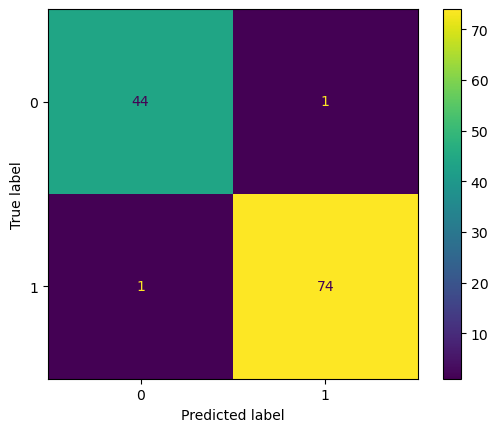

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()